In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

What are the most efficient factory to customer shipping routes?

What are the least efficient factory to customer shipping routes?

Which product lines have the best product margin?

Which product lines should be moved to a different factory to optimize shipping routes?

In [2]:
dictionary = pd.read_csv("candy_distributor_data_dictionary.csv")
zips = pd.read_csv("uszips.csv")
factories = pd.read_csv("Candy_Factories.csv")
products = pd.read_csv("Candy_Products.csv")
sales = pd.read_csv("Candy_Sales.csv")
targets = pd.read_csv("Candy_Targets.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'candy_distributor_data_dictionary.csv'

In [ ]:
zips.info()

<class 'pandas.DataFrame'>
RangeIndex: 33787 entries, 0 to 33786
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   zip               33787 non-null  int64  
 1   lat               33787 non-null  float64
 2   lng               33787 non-null  float64
 3   city              33787 non-null  str    
 4   state_id          33787 non-null  str    
 5   state_name        33787 non-null  str    
 6   zcta              33787 non-null  bool   
 7   parent_zcta       0 non-null      float64
 8   population        33770 non-null  float64
 9   density           33770 non-null  float64
 10  county_fips       33787 non-null  int64  
 11  county_name       33787 non-null  str    
 12  county_weights    33787 non-null  str    
 13  county_names_all  33787 non-null  str    
 14  county_fips_all   33787 non-null  str    
 15  imprecise         33787 non-null  bool   
 16  military          33787 non-null  bool   
 17  time

In [ ]:
factories

,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


In [ ]:
products


,Division,Product Name,Factory,Product ID,Unit Price,Unit Cost
0,Chocolate,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,CHO-NUT-13000,3.49,1.00
1,Chocolate,Wonka Bar - Fudge Mallows,Lot's O' Nuts,CHO-FUD-51000,3.60,1.20
2,Chocolate,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,CHO-SCR-58000,3.60,1.10
3,Chocolate,Wonka Bar - Milk Chocolate,Wicked Choccy's,CHO-MIL-31000,3.25,1.14
4,Chocolate,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,CHO-TRI-54000,3.75,1.30
5,Sugar,Laffy Taffy,Sugar Shack,SUG-LAF-25000,1.99,0.75
6,Sugar,SweeTARTS,Sugar Shack,SUG-SWE-91000,1.50,0.80
7,Sugar,Nerds,Sugar Shack,SUG-NER-92000,1.50,0.80
8,Sugar,Fun Dip,Sugar Shack,SUG-FUN-75000,1.50,0.90
9,Other,Fizzy Lifting Drinks,Sugar Shack,OTH-FIZ-56000,3.75,1.50


In [ ]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [ ]:
targets

,Division,Target
0,Chocolate,27000
1,Sugar,15000
2,Other,3000


In [ ]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20
2,1132,US-2021-138100-CHO-FUD-51000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,Chocolate,Atlantic,CHO-FUD-51000,Wonka Bar - Fudge Mallows,7.20,2,4.80,2.40
3,1133,US-2021-138100-CHO-MIL-31000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
4,3396,US-2022-121391-CHO-MIL-31000,2022-10-04,2028-03-29,First Class,121391,United States,San Francisco,California,94109,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28


In [ ]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [ ]:
sales.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [ ]:
sales.duplicated().sum()

np.int64(0)

##### Sales data does not contain any null values, and no duplicate rows. we need to convert the order date and ship date from string datatype to datetime

In [ ]:
sales['Order Date'] = pd.to_datetime(sales['Order Date'])
sales['Ship Date'] = pd.to_datetime(sales['Ship Date'])
sales['profit margin %']= round(sales['Gross Profit']*100 /sales['Sales'], 2 )

In [ ]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row ID           10194 non-null  int64         
 1   Order ID         10194 non-null  str           
 2   Order Date       10194 non-null  datetime64[us]
 3   Ship Date        10194 non-null  datetime64[us]
 4   Ship Mode        10194 non-null  str           
 5   Customer ID      10194 non-null  int64         
 6   Country/Region   10194 non-null  str           
 7   City             10194 non-null  str           
 8   State/Province   10194 non-null  str           
 9   Postal Code      10194 non-null  str           
 10  Division         10194 non-null  str           
 11  Region           10194 non-null  str           
 12  Product ID       10194 non-null  str           
 13  Product Name     10194 non-null  str           
 14  Sales            10194 non-null  float64       
 

In [ ]:
sales = sales.merge(products, how='left', left_on=['Product ID', 'Product Name', 'Division'],
                    right_on=['Product ID', 'Product Name', 'Division'])

In [ ]:
sales.shape

(10194, 22)

### KPIs

In [ ]:
print(f"Total Orders : {sales['Order ID'].nunique()}")
print(f"Total Revenue : {round(sales['Sales'].sum()/1e3, 2)}K $" )
print(f"Total Revenue : {round(sales['Gross Profit'].sum()/1e3, 2)}K $" )
print(f"Products : {sales['Product ID'].nunique()}")
print(f"Total Customers : {sales['Customer ID'].nunique()}")

Total Orders : 8549
Total Revenue : 141.78K $
Total Revenue : 93.44K $
Products : 15
Total Customers : 5044


In [ ]:
sales["order_month_year"] = sales['Order Date'].dt.strftime("%b-%Y")
sales["order_month_year"] = pd.to_datetime(sales["order_month_year"])

In [ ]:
sales_monthwise = sales.groupby('order_month_year').agg(orders = ('Order ID', 'nunique'), units = ('Units', 'sum'), revenue = ('Sales', sum), 
                                                        profit = ("Gross Profit", 'sum'), cost = ('Cost', "sum"), profit_margin = ('profit margin %', 'mean')).reset_index()
sales_monthwise

,order_month_year,orders,units,revenue,profit,cost,profit_margin
0,2021-01-01,61,306,1065.24,704.00,361.24,65.682619
1,2021-02-01,40,159,547.09,358.07,189.02,65.278478
2,2021-03-01,132,597,2245.63,1425.29,820.34,64.764780
3,2021-04-01,113,536,2058.97,1325.13,733.84,66.737556
4,2021-05-01,118,504,1855.21,1208.23,646.98,65.556439
5,2021-06-01,118,524,1838.43,1218.69,619.74,66.427353
6,2021-07-01,113,550,1908.23,1265.25,642.98,65.648112
7,2021-08-01,131,624,2258.46,1475.44,783.02,65.803924
8,2021-09-01,234,1015,3927.08,2552.90,1374.18,66.656740
9,2021-10-01,138,605,2544.88,1624.84,920.04,66.646845


Text(0.5, 1.0, 'Monthly Oreders trend')

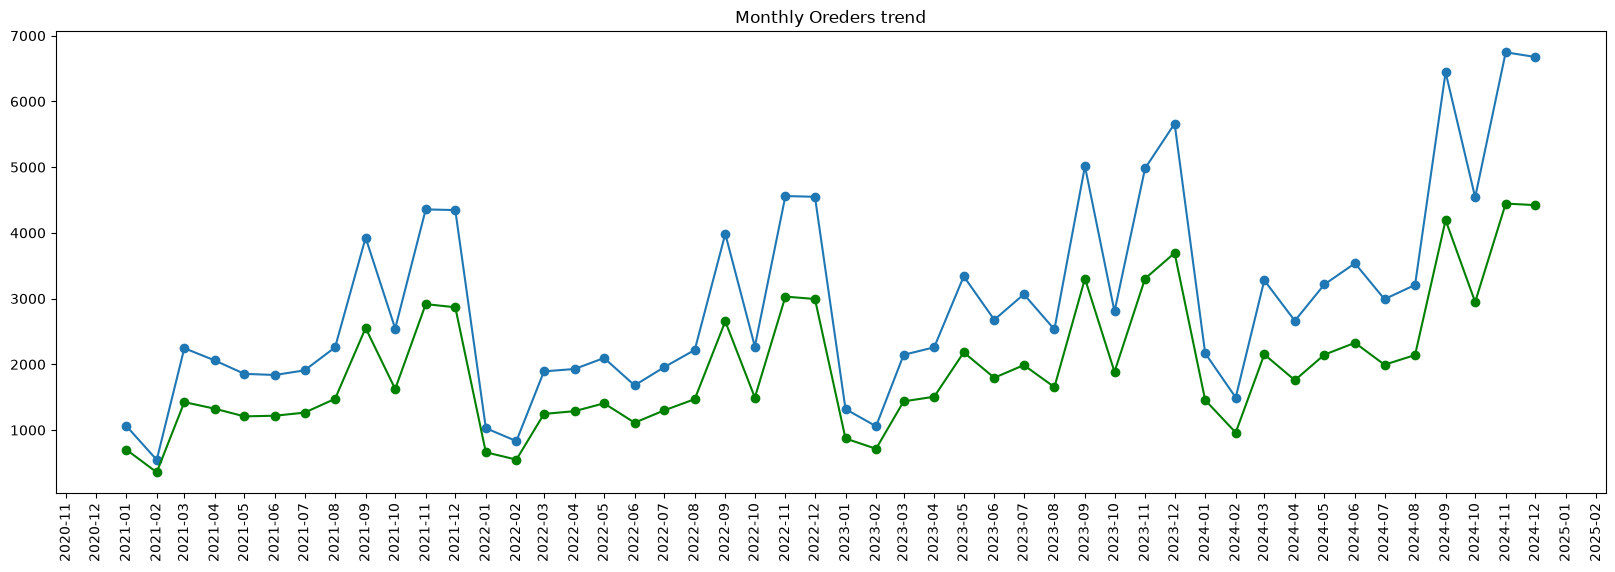

In [ ]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(20, 6))

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

# 3. Format how the dates look (YYYY-MM to match your image)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# 4. Rotate the labels so they don't overlap
plt.xticks(rotation=90)


plt.plot(sales_monthwise['order_month_year'], sales_monthwise['revenue'], marker = 'o')
plt.plot(sales_monthwise['order_month_year'], sales_monthwise['profit'], marker = 'o', color = 'g')

plt.xticks( rotation =90 )
plt.title('Monthly Oreders trend')

In [ ]:
sales_product = sales.groupby('Product Name').agg(orders = ('Order ID', 'nunique'), units = ('Units', 'sum'), revenue = ('Sales', sum), 
                                                        profit = ("Gross Profit", 'sum'), cost = ('Cost', "sum"), profit_margin = ('profit margin %', 'mean')).reset_index()
sales_product.sort_values('revenue', ascending=False)

,Product Name,orders,units,revenue,profit,cost,profit_margin
12,Wonka Bar - Triple Dazzle Caramel,1677,7596,28485.00,18610.20,9874.80,65.33
13,Wonka Bar -Scrumdiddlyumptious,1704,7743,27874.80,19357.50,8517.30,69.44
10,Wonka Bar - Milk Chocolate,1768,8267,26867.75,17443.37,9424.38,64.92
9,Wonka Bar - Fudge Mallows,1527,6914,24890.40,16593.60,8296.80,66.67
11,Wonka Bar - Nutty Crunch Surprise,1529,6755,23574.95,16819.95,6755.00,71.35
6,Lickable Wallpaper,92,393,7860.00,3930.00,3930.00,50.00
4,Kazookles,94,371,1205.75,92.75,1113.00,7.69
14,Wonka Gum,118,478,597.50,310.70,286.80,52.00
0,Everlasting Gobstopper,3,13,130.00,104.00,26.00,80.00
1,Fizzy Lifting Drinks,6,21,78.75,47.25,31.50,60.00


Text(0.5, 1.0, 'Profit by Product')

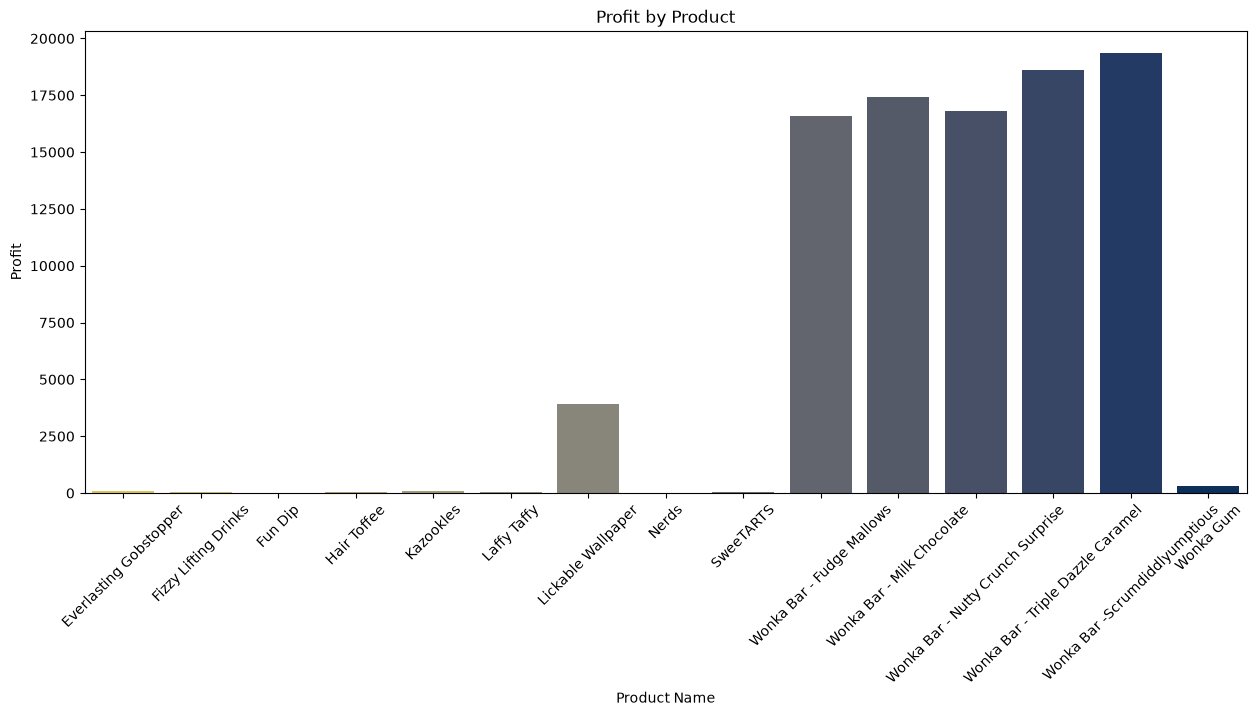

In [ ]:
plt.figure(figsize=(15,6))
sns.barplot(sales_product, y = sales_product['profit'], x= sales_product['Product Name'], palette='cividis_r')

plt.xlabel('Product Name')
plt.ylabel('Profit')
plt.xticks(rotation = 45)
plt.title("Profit by Product")

In [ ]:
sales_division = sales.groupby('Division').agg(orders = ('Order ID', 'nunique'), units = ('Units', 'sum'), revenue = ('Sales', sum), 
                                                        profit = ("Gross Profit", 'sum'), cost = ('Cost', "sum"), profit_margin = ('profit margin %', 'mean')).reset_index()
sales_division.sort_values('revenue', ascending= False)

,Division,orders,units,revenue,profit,cost,profit_margin
0,Chocolate,8205,37275,131692.90,88824.62,42868.28,67.457102
1,Other,304,1242,9663.25,4333.45,5329.80,37.671742
2,Sugar,40,137,427.48,284.73,142.75,57.690000


In [ ]:
targets.columns

Index(['Division', 'Target'], dtype='str')

Text(0.5, 1.0, 'Profit by Division')

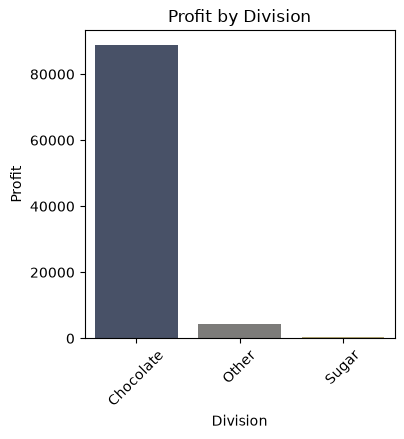

In [ ]:
plt.figure(figsize=(4,4))
sns.barplot(sales_division, y = sales_division['profit'], x= sales_division['Division'], palette='cividis')

plt.xlabel('Division')
plt.ylabel('Profit')
plt.xticks(rotation = 45)
plt.title("Profit by Division")

In [ ]:
sales_division_target = sales_division.merge(targets, how= 'left', on = 'Division')
sales_division_target

,Division,orders,units,revenue,profit,cost,profit_margin,Target
0,Chocolate,8205,37275,131692.90,88824.62,42868.28,67.457102,27000
1,Other,304,1242,9663.25,4333.45,5329.80,37.671742,3000
2,Sugar,40,137,427.48,284.73,142.75,57.690000,15000


In [ ]:
sales_cities = sales.groupby('City').agg(orders = ('Order ID', 'nunique'), units = ('Units', 'sum'), revenue = ('Sales', sum), 
                                                        profit = ("Gross Profit", 'sum'), cost = ('Cost', "sum"), profit_margin = ('profit margin %', 'mean')).reset_index()
top_10_cities = sales_cities.sort_values('profit', ascending= False).head(10)
top_10_cities

,City,orders,units,revenue,profit,cost,profit_margin
335,New York City,761,3417,12514.90,8240.51,4274.39,66.286426
270,Los Angeles,629,2879,10408.75,6898.61,3510.14,66.725328
380,Philadelphia,450,1981,7415.52,4813.82,2601.70,66.092402
446,San Francisco,430,1935,7018.61,4650.77,2367.84,66.374569
460,Seattle,362,1590,5893.39,3880.68,2012.71,66.473621
211,Houston,323,1466,5429.41,3547.43,1881.98,66.457958
82,Chicago,276,1132,4263.92,2800.58,1463.34,66.755318
96,Columbus,188,836,3357.39,2159.03,1198.36,66.504955
445,San Diego,149,670,2348.88,1567.52,781.36,66.550706
472,Springfield,133,649,2375.00,1540.12,834.88,64.915460


Text(0.5, 1.0, 'Profit by Cities')

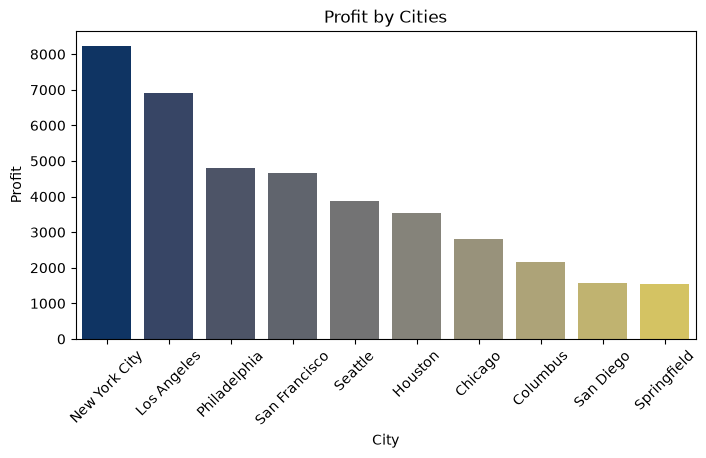

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(top_10_cities, y = top_10_cities['profit'], x= top_10_cities['City'], palette='cividis')

plt.xlabel('City')
plt.ylabel('Profit')
plt.xticks(rotation = 45)
plt.title("Profit by Cities")

In [ ]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID            10194 non-null  int64         
 1   Order ID          10194 non-null  str           
 2   Order Date        10194 non-null  datetime64[us]
 3   Ship Date         10194 non-null  datetime64[us]
 4   Ship Mode         10194 non-null  str           
 5   Customer ID       10194 non-null  int64         
 6   Country/Region    10194 non-null  str           
 7   City              10194 non-null  str           
 8   State/Province    10194 non-null  str           
 9   Postal Code       10194 non-null  str           
 10  Division          10194 non-null  str           
 11  Region            10194 non-null  str           
 12  Product ID        10194 non-null  str           
 13  Product Name      10194 non-null  str           
 14  Sales             10194 non-null 

In [ ]:
zips['zip'].nunique()

33787

In [ ]:
sales['Postal Code'] = sales['Postal Code'].apply(lambda x : x.lstrip('0')) 

In [ ]:
zips['zip'] = zips['zip'].astype('str')

In [ ]:
location_customer = sales.merge(zips, how='left', left_on='Postal Code', right_on='zip')
location_customer[location_customer['lat'].isnull()]['Postal Code'].unique()

<StringArray>
['V5K', 'M2N', 'H1C', 'H1A', 'M3C', 'G1B', 'V6Z', 'M5H', 'H1B', 'V6G', 'T1Y',
 'T5A', 'C0A', 'R0H', 'V6E', 'A0A', 'M7A', 'E1A', 'B3H', 'T2C', 'S0G', 'V6B',
 'R3R']
Length: 23, dtype: str

In [ ]:
loca = pd.read_csv('dim_location.csv')

In [ ]:
loca['customer_id'].nunique()

5009

In [ ]:
location_customer['Customer ID'].nunique()

5044

#### Since we only have ZIP of only US country hence we exclude the customers from Canada since all the ZIP table entries for these would be null

In [ ]:
location_customer_us = location_customer[location_customer['Country/Region'] != 'Canada']
location_customer_us.info()

<class 'pandas.DataFrame'>
Index: 9994 entries, 0 to 10193
Data columns (total 41 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID            9994 non-null   int64         
 1   Order ID          9994 non-null   str           
 2   Order Date        9994 non-null   datetime64[us]
 3   Ship Date         9994 non-null   datetime64[us]
 4   Ship Mode         9994 non-null   str           
 5   Customer ID       9994 non-null   int64         
 6   Country/Region    9994 non-null   str           
 7   City              9994 non-null   str           
 8   State/Province    9994 non-null   str           
 9   Postal Code       9994 non-null   str           
 10  Division          9994 non-null   str           
 11  Region            9994 non-null   str           
 12  Product ID        9994 non-null   str           
 13  Product Name      9994 non-null   str           
 14  Sales             9994 non-null   float

In [ ]:
location_customer_us = location_customer_us.merge( factories, how = 'left', on = 'Factory')

### Haversine distance formula

In [ ]:
# Vectorized Haversine distance formula (faster than looping rows)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [ ]:
location_customer_us['haversine_distance'] = haversine_distance(location_customer_us['lat'], location_customer_us['lng'],
                                                                    location_customer_us['Latitude'], location_customer_us['Longitude'])

In [ ]:
sales_by_route = location_customer_us.groupby(['Factory', 'Postal Code', 'city', 'state_id']).agg(
    orders = ('Order ID', 'nunique'),
    units = ('Units', 'sum'),
    revenue = ('Sales', 'sum'),
    profit = ('Gross Profit', 'sum'),
    cost = ('Cost', 'sum'),
    profit_margin = ('profit margin %', 'mean'),
    haversine_distance = ('haversine_distance', 'first') ).reset_index()  # constant within a route, just carry it along

In [ ]:
sales_by_route['profit_per_mile'] = sales_by_route['profit']/sales_by_route['haversine_distance']

In [ ]:
### keeping the minimum order threshold as 3 to determine efficient routes
sales_by_route_established = sales_by_route[sales_by_route['orders'] >= 3]  # pick your own threshold

In [ ]:
sales_by_route_established[sales_by_route['profit_per_mile'] > sales_by_route_established['profit_per_mile'].quantile(.99)].sort_values('profit_per_mile', ascending=False)

,Factory,Postal Code,city,state_id,orders,units,revenue,profit,cost,profit_margin,haversine_distance,profit_per_mile
454,Lot's O' Nuts,85204,Mesa,AZ,13,77,276.32,190.02,86.30,68.771333,35.585847,5.339763
453,Lot's O' Nuts,85023,Phoenix,AZ,22,70,248.81,173.31,75.50,69.499583,55.125407,3.143922
464,Lot's O' Nuts,85705,Tucson,AZ,13,74,263.65,183.25,80.40,69.344375,61.834363,2.963562
912,Wicked Choccy's,32216,Jacksonville,FL,25,121,417.25,271.63,145.62,65.112188,127.576563,2.129153
459,Lot's O' Nuts,85301,Glendale,AZ,14,43,152.93,106.53,46.40,69.810000,50.803685,2.096895
485,Lot's O' Nuts,90049,Los Angeles,CA,69,322,1146.44,793.44,353.00,69.498554,396.124475,2.003007
456,Lot's O' Nuts,85234,Gilbert,AZ,5,26,92.83,63.23,29.60,69.071429,33.406913,1.892722


In [ ]:
sales_by_route.shape

(1344, 12)

In [ ]:
sales_by_route_established[sales_by_route['profit_per_mile'] < sales_by_route_established['profit_per_mile'].quantile(.01)].sort_values('profit_per_mile', ascending=False)

,Factory,Postal Code,city,state_id,orders,units,revenue,profit,cost,profit_margin,haversine_distance,profit_per_mile
1300,Wicked Choccy's,94533,Fairfield,CA,3,7,25.25,16.47,8.78,65.2275,2330.945572,0.007066
709,Sugar Shack,10011,New York,NY,4,10,16.47,8.22,8.25,52.8225,1201.563458,0.006841
746,The Other Factory,22153,Springfield,VA,3,13,42.25,3.25,39.00,7.6900,745.967083,0.004357
740,The Other Factory,19134,Philadelphia,PA,3,13,42.25,3.25,39.00,7.6900,879.565136,0.003695
732,The Other Factory,10009,New York,NY,3,11,35.75,2.75,33.00,7.6900,952.053072,0.002888
735,The Other Factory,10035,New York,NY,3,7,22.75,1.75,21.00,7.6900,956.028082,0.001830
796,The Other Factory,94122,San Francisco,CA,4,12,39.00,3.00,36.00,7.6900,1807.360653,0.001660


In [ ]:
orders_us = location_customer_us[['Order ID', 'Product Name', 'Division', 'Factory',
                                     'Units', 'Sales', 'Gross Profit',
                                     'lat', 'lng', 'haversine_distance']].copy()

In [ ]:
orders_us.shape

(9994, 10)

In [ ]:
orders_all_factories = orders_us.merge(factories, how='cross')

In [ ]:
orders_all_factories.shape

(49970, 13)

In [ ]:
orders_all_factories['haversine_distance_facories'] = haversine_distance(orders_all_factories['lat'], orders_all_factories['lng'],
                                                                            orders_all_factories['Latitude'], orders_all_factories['Longitude'])

In [ ]:
required_factories = orders_all_factories[orders_all_factories['haversine_distance_facories'] < orders_all_factories['haversine_distance']]
required_factories

,Order ID,Product Name,Division,Factory_x,Units,Sales,Gross Profit,lat,lng,haversine_distance,Factory_y,Latitude,Longitude,haversine_distance_facories
0,US-2021-128055-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,Wicked Choccy's,2,7.50,4.90,37.76113,-122.48433,2358.537678,Lot's O' Nuts,32.881893,-111.768036,691.174953
2,US-2021-128055-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,Wicked Choccy's,2,7.50,4.90,37.76113,-122.48433,2358.537678,Sugar Shack,48.119140,-96.181150,1500.130028
3,US-2021-128055-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,Wicked Choccy's,2,7.50,4.90,37.76113,-122.48433,2358.537678,Secret Factory,41.446333,-90.565487,1708.302421
4,US-2021-128055-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,Wicked Choccy's,2,7.50,4.90,37.76113,-122.48433,2358.537678,The Other Factory,35.117500,-89.971107,1807.360653
11,US-2021-138100-CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,Lot's O' Nuts,2,7.20,4.80,40.74173,-74.00037,2140.848363,Wicked Choccy's,32.076176,-81.088371,716.230343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49949,US-2023-167682-CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,Lot's O' Nuts,4,14.40,10.00,39.83376,-84.88997,1563.874748,The Other Factory,35.117500,-89.971107,428.575309
49951,US-2023-147991-CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,Lot's O' Nuts,5,17.45,12.45,35.02915,-85.15300,1528.018429,Wicked Choccy's,32.076176,-81.088371,310.439301
49952,US-2023-147991-CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,Lot's O' Nuts,5,17.45,12.45,35.02915,-85.15300,1528.018429,Sugar Shack,48.119140,-96.181150,1066.651941
49953,US-2023-147991-CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,Lot's O' Nuts,5,17.45,12.45,35.02915,-85.15300,1528.018429,Secret Factory,41.446333,-90.565487,531.593425


In [ ]:
alt_factories  = required_factories.groupby(['Order ID', 'Product Name', 'Factory_x']).agg(   
    units = ('Units', 'first')
    ,sales = ('Sales', 'first')
    , profit = ('Gross Profit', 'first'),
    alt_haversine_distance = ('haversine_distance_facories', 'min') ).reset_index()  # constant within a route, just carry it along

In [ ]:
alt_factories.shape

(5698, 7)

In [ ]:
###### alt_factories.merge(required_factories, how = 'inner', left_on=['Order ID', 'Product Name', 'Factory_x', 'units', 'sales', 'profit', 'alt_haversine_distance'] ,
       ##            right_on= ['Order ID', 'Product Name', 'Factory_x', 'Units', 'Sales', 'Gross Profit', 'haversine_distance_facories'] )

In [ ]:
idx = required_factories.groupby(['Order ID', 'Product Name'])['haversine_distance_facories'].idxmin()

## get the idx rows 'Order ID', 'Product Name', 'Factory_y', 'haversine_distance_facories'
alt_factories = required_factories.loc[idx, ['Order ID', 'Product Name', 'Factory_x', 'Factory_y', 'haversine_distance_facories']]

### rename the columns
alt_factories = alt_factories.rename(columns={'Factory_x' : 'actual_factory', 'Factory_y': 'best_alt_factory', 
                                               'haversine_distance_facories': 'alt_haversine_distance'})

In [ ]:
### Per order nearest factory - best option
alt_factories

,Order ID,Product Name,actual_factory,best_alt_factory,alt_haversine_distance
15230,US-2021-100090-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,691.174953
45818,US-2021-100279-CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Secret Factory,387.152993
34986,US-2021-100293-CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,127.576563
24260,US-2021-100363-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,50.803685
27369,US-2021-100678-CHO-FUD-51000,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,488.898842
...,...,...,...,...,...
38897,US-2024-169810-CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Sugar Shack,317.483225
33400,US-2024-169859-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,318.345503
34010,US-2024-169894-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,35.585847
29707,US-2024-169929-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Sugar Shack,755.450446


Per-order nearest-factory doesn't answer a per-product reassignment question.


In [ ]:
#######alt_factories = (required_factories
 #   .sort_values('haversine_distance_facories')
  #  .drop_duplicates(subset=['Order ID', 'Product Name'], keep='first')
   # [['Order ID', 'Product Name', 'Factory_y', 'haversine_distance_facories']]
    #.rename(columns={'Factory_y': 'best_alt_factory',
     #                 'haversine_distance_facories': 'alt_haversine_distance'}))

In [ ]:
# Fix a candidate factory, sum volume-weighted distance across ALL of a product's orders
product_factory_cost = (orders_all_factories
    .assign(weighted = orders_all_factories['haversine_distance_facories'] * orders_all_factories['Units'])
    .groupby(['Product Name', 'Factory_y'])['weighted']
    .sum()
    .unstack())   # columns = candidate factories, rows = products

current_factory = orders_us.groupby('Product Name')['Factory'].first()
current_cost = (orders_us.assign(weighted = orders_us['haversine_distance'] * orders_us['Units'])
                          .groupby('Product Name')['weighted'].sum())

comparison = pd.DataFrame({'current_factory': current_factory, 'current_cost': current_cost})
comparison['best_factory']  = product_factory_cost.idxmin(axis=1)
comparison['best_cost']     = product_factory_cost.min(axis=1)
comparison['savings_pct']   = round((comparison['current_cost'] - comparison['best_cost'])
                                     / comparison['current_cost'] * 100, 1)

candidates = comparison[comparison['current_factory'] != comparison['best_factory']]
candidates.reset_index().sort_values('savings_pct', ascending=False)

,Product Name,current_factory,current_cost,best_factory,best_cost,savings_pct
4,Laffy Taffy,Sugar Shack,3.437299e+04,Wicked Choccy's,1.594389e+04,53.6
2,Fun Dip,Sugar Shack,7.667897e+03,Secret Factory,4.430979e+03,42.2
5,Nerds,Sugar Shack,1.199171e+04,Wicked Choccy's,7.106721e+03,40.7
9,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,8.783053e+06,Secret Factory,6.175292e+06,29.7
11,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,9.987021e+06,Secret Factory,7.141426e+06,28.5
7,Wonka Bar - Fudge Mallows,Lot's O' Nuts,8.979884e+06,Secret Factory,6.435308e+06,28.3
6,SweeTARTS,Sugar Shack,4.404703e+04,Secret Factory,3.171150e+04,28.0
0,Everlasting Gobstopper,Secret Factory,1.050403e+04,The Other Factory,8.279014e+03,21.2
10,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,8.878833e+06,Secret Factory,7.162169e+06,19.3
3,Hair Toffee,The Other Factory,2.016443e+04,Lot's O' Nuts,1.648949e+04,18.2


In [ ]:
orders_all_factories['weighted'] = orders_all_factories['haversine_distance_facories'] * orders_all_factories['Units']

product_factory_cost = orders_all_factories.groupby(['Product Name', 'Factory_y'])['weighted'].sum().unstack()

current_factory = orders_us.groupby('Product Name')['Factory'].first()
orders_us['weighted'] = orders_us['haversine_distance'] * orders_us['Units']
current_cost = orders_us.groupby('Product Name')['weighted'].sum()

comparison = pd.DataFrame({'current_factory': current_factory, 'current_cost': current_cost})
comparison['best_factory']  = product_factory_cost.idxmin(axis=1)
comparison['best_cost']     = product_factory_cost.min(axis=1)
comparison['savings_pct']   = round((comparison['current_cost'] - comparison['best_cost'])
                                     / comparison['current_cost'] * 100, 1)

candidates = comparison[comparison['current_factory'] != comparison['best_factory']]
candidates.reset_index().sort_values('savings_pct', ascending=False)

,Product Name,current_factory,current_cost,best_factory,best_cost,savings_pct
4,Laffy Taffy,Sugar Shack,3.437299e+04,Wicked Choccy's,1.594389e+04,53.6
2,Fun Dip,Sugar Shack,7.667897e+03,Secret Factory,4.430979e+03,42.2
5,Nerds,Sugar Shack,1.199171e+04,Wicked Choccy's,7.106721e+03,40.7
9,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,8.783053e+06,Secret Factory,6.175292e+06,29.7
11,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,9.987021e+06,Secret Factory,7.141426e+06,28.5
7,Wonka Bar - Fudge Mallows,Lot's O' Nuts,8.979884e+06,Secret Factory,6.435308e+06,28.3
6,SweeTARTS,Sugar Shack,4.404703e+04,Secret Factory,3.171150e+04,28.0
0,Everlasting Gobstopper,Secret Factory,1.050403e+04,The Other Factory,8.279014e+03,21.2
10,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,8.878833e+06,Secret Factory,7.162169e+06,19.3
3,Hair Toffee,The Other Factory,2.016443e+04,Lot's O' Nuts,1.648949e+04,18.2


In [ ]:
product_factory_cost

Factory_y,Lot's O' Nuts,Secret Factory,Sugar Shack,The Other Factory,Wicked Choccy's
Product Name,,,,,
Everlasting Gobstopper,1.278009e+04,1.050403e+04,1.407316e+04,8.279014e+03,1.176133e+04
Fizzy Lifting Drinks,3.400579e+04,1.636083e+04,2.374245e+04,1.704320e+04,1.566647e+04
Fun Dip,1.444792e+04,4.430979e+03,7.667897e+03,5.519848e+03,5.477495e+03
Hair Toffee,1.648949e+04,2.011303e+04,2.237322e+04,2.016443e+04,2.370612e+04
Kazookles,5.484318e+05,3.691091e+05,4.547636e+05,3.664726e+05,4.046874e+05
Laffy Taffy,5.115350e+04,2.358198e+04,3.437299e+04,2.205654e+04,1.594389e+04
Lickable Wallpaper,4.895169e+05,3.529639e+05,4.267114e+05,3.765142e+05,4.545745e+05
Nerds,2.135619e+04,8.582282e+03,1.199171e+04,9.454590e+03,7.106721e+03
SweeTARTS,6.411752e+04,3.171150e+04,4.404703e+04,3.324400e+04,3.774729e+04


In [ ]:
import pandas as pd
df = pd.read_csv('data/raw/Candy_Sales.csv')
print(df['Sales'].sum(), df['Gross Profit'].sum(), df['Cost'].sum(), df['Units'].sum())

141783.63 93442.79999999999 48340.83 38654
